In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.spatial import KDTree
%matplotlib inline

In [24]:
# Load data

data = loadmat('v1_laminar.mat')
data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'csd', 'timevec', 'srate'])

In [25]:
# Initialize Parameters

eeg_data = data['csd']
time_vector = data['timevec'][0]
sampling_rate = data['srate'][0, 0]
timepoints = 1527
trials = 200
channel = 5

eeg_data.shape, time_vector.shape, sampling_rate

((16, 1527, 200), (1527,), np.float64(762.939453125))

In [26]:
# Create Signal Vector From A Single Channel

signal = eeg_data[channel, :, :]
signal.shape

(1527, 200)

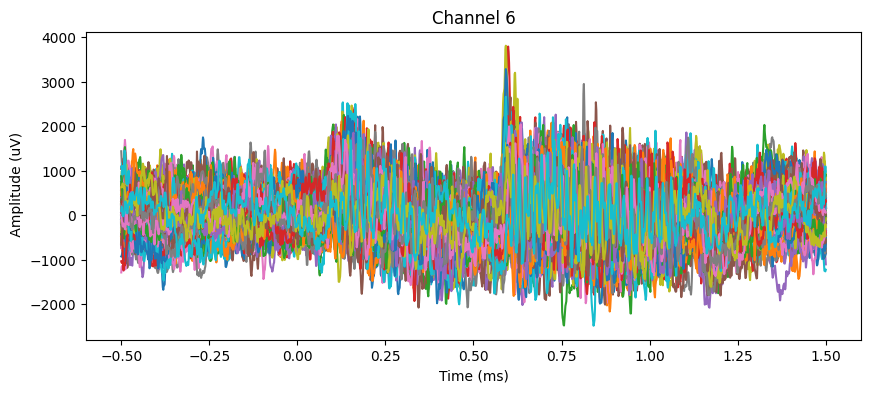

In [27]:
# Plot Signal

plt.close('all')
plt.figure(figsize=(10, 4))
plt.plot(time_vector, signal)
plt.xlabel('Time (ms)')
plt.ylabel(' Amplitude (uV)')
plt.title(f'Channel {channel+1}')
plt.show()

In [28]:
# Reshape Signal Into 1 Dimension To Reduce Computational Time

signal_1d = np.reshape(signal, (-1), order='F')
signal_1d.shape

(305400,)

In [29]:
# Time-Frequency Variables

min_frequency = 5
max_frequency = 90
total_frequencies = 30
frequencies = np.linspace(min_frequency, max_frequency, total_frequencies)

# Time-Frequency Vectors

tf_power = np.zeros((total_frequencies, timepoints))
tf_baseline_power = np.zeros((total_frequencies, timepoints))

In [30]:
# Frequency multiplication parameters

fwhm = 0.3
kernel_time = np.arange(-2, 2-1/sampling_rate, 1/sampling_rate)
n_conv = len(signal_1d) + len(kernel_time) - 1
half_kernel = int(len(kernel_time) / 2)

In [31]:
# Baseline Window

baseline_time_window = np.array([[-.5, -.2]]) # from 0.5 seconds before stimilus to 0.2 seconds before stimulus

kdt = KDTree(time_vector.reshape(timepoints, 1))
_, base_idx = kdt.query(baseline_time_window.T)

time_vector[base_idx]

array([-0.49992064, -0.19976576])

In [32]:
# Extract Time-Frequency Power Via Frequency Domain Multiplication

for i in range(total_frequencies):
  # Create A Complex Morlet Wavelet As Kernel
  csm = np.exp(1j * 2 * np.pi * frequencies[i] * kernel_time) * np.exp(-4 * np.log(2) * (kernel_time ** 2) / (fwhm ** 2))

  # Fast Fourier Transform To Switch To Frequency Domain
  sig_coef = np.fft.fft(signal_1d, n=n_conv)
  kern_coef = np.fft.fft(csm, n=n_conv)
  kern_coef = kern_coef / np.max(kern_coef)

  # Frequency Domain Multiplication And Inverse Fourier Transform To Switch Back Into Time Domain
  res = np.fft.ifft(sig_coef * kern_coef)

  # Post-Processing - clipping, reshaping
  res = res[half_kernel-1 : -half_kernel-1]
  res = np.reshape(res, (timepoints, trials), order='F')

  # Average Of Power Within Baseline Window Accross Trials
  power_average = np.mean(((np.abs(res)) ** 2), axis = 1)
  baseline_power_average = np.mean(power_average[base_idx[0] : base_idx[1]])

  # Extracting Time-Frequency Power And Baseline Normalized Power
  tf_power[i, :] = power_average
  tf_baseline_power[i, :] = 10 * np.log10(power_average / baseline_power_average)

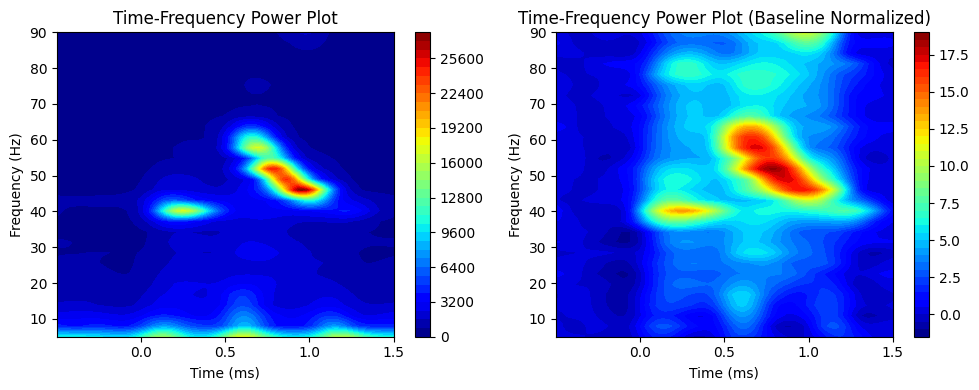

In [35]:
# visualize Time-Frequency Power And Time-Frequency Baseline-Normalized Power

plt.close('all')
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

cf = ax[0].contourf(time_vector, frequencies, tf_power, 40, cmap='jet')
fig.colorbar(cf, ax=ax[0])
ax[0].set_xlabel('Time (ms)')
ax[0].set_ylabel('Frequency (Hz)')
ax[0].set_title('Time-Frequency Power Plot')

cf2 = ax[1].contourf(time_vector, frequencies, tf_baseline_power, 40, cmap='jet')
fig.colorbar(cf2, ax=ax[1],)
ax[1].set_xlabel('Time (ms)')
ax[1].set_ylabel('Frequency (Hz)')
ax[1].set_title('Time-Frequency Power Plot (Baseline Normalized)')

plt.tight_layout()
plt.show()